In [6]:
import torch
import torch.nn as nn
from transformers import (
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    RobertaModel,
    DataCollatorWithPadding,
)
from transformers.modeling_outputs import SequenceClassifierOutput

from datasets import Dataset
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import json
import os
from datetime import datetime

print("="*70)
print("MENTAL HEALTH TEXT CLASSIFICATION TRAINING")
print("="*70)


# ============= LOAD CLASS MAPPING =============

print("\n[1/6] Loading class configuration...")

try:
    with open('models/mental_health_roberta/label_mapping.json', 'r') as f:
        label_mapping = json.load(f)
    
    with open('models/mental_health_roberta/class_weights.json', 'r') as f:
        class_weights_dict = json.load(f)
    
    NUM_LABELS = len(label_mapping)
    class_weights = torch.tensor([class_weights_dict[str(i)] for i in range(NUM_LABELS)])
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

    print(f"+ Loaded configuration:")
    print(f"   Number of classes: {NUM_LABELS}")
    print(f"   Classes: {list(label_mapping.keys())}")
    
except Exception as e:
    print(f"? Error loading configuration: {e}")
    exit(1)


# ============= MODEL DEFINITIONS =============

class RobertaBiLSTMCNNClassifier(nn.Module):
    def __init__(
        self,
        model_name: str,
        num_labels: int,
        lstm_hidden: int = 256,
        lstm_layers: int = 1,
        bidirectional: bool = True,
        num_filters: int = 128,
        kernel_sizes=(2, 3, 4),
        dropout: float = 0.35
    ):
        super().__init__()

        self.num_labels = num_labels
        self.roberta = RobertaModel.from_pretrained(model_name)

        hidden_size = self.roberta.config.hidden_size
        lstm_out_dim = lstm_hidden * (2 if bidirectional else 1)

        self.lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=bidirectional
        )

        self.lstm_norm = nn.LayerNorm(lstm_out_dim)

        self.convs = nn.ModuleList([
            nn.Conv1d(hidden_size, num_filters, k) for k in kernel_sizes
        ])

        cnn_out_dim = num_filters * len(kernel_sizes)
        final_dim = hidden_size + lstm_out_dim + cnn_out_dim

        self.fc_norm = nn.LayerNorm(final_dim)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(final_dim, num_labels)

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        roberta_outputs = self.roberta(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True
        )

        sequence_output = roberta_outputs.last_hidden_state  # (B,T,H)
        cls_embedding = sequence_output[:, 0, :]             # (B,H)

        # BiLSTM
        lstm_out, _ = self.lstm(sequence_output)
        lstm_out = self.lstm_norm(lstm_out)

        mask = attention_mask.unsqueeze(-1).float()
        lstm_pooled = (lstm_out * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)

        # CNN
        x_cnn = sequence_output.transpose(1, 2)  # (B,H,T)
        cnn_feats = []
        for conv in self.convs:
            conv_out = torch.relu(conv(x_cnn))
            pooled = torch.max(conv_out, dim=2).values
            cnn_feats.append(pooled)

        cnn_pooled = torch.cat(cnn_feats, dim=1)

        combined = torch.cat([cls_embedding, lstm_pooled, cnn_pooled], dim=1)
        combined = self.fc_norm(combined)
        combined = self.dropout(combined)

        logits = self.classifier(combined)
        return SequenceClassifierOutput(logits=logits)


# ============= CONFIGURATION =============

CONFIG = {
    "model_name": "FacebookAI/roberta-base",
    "max_length": 512,
    "num_labels": 7,
    "batch_size": 8,
    "num_epochs": 4,
    "learning_rate": 2e-5,
    "weight_decay": 0.01,
    "warmup_ratio": 0.1,
    "gradient_accumulation_steps": 4,
    "eval_steps": 200,
    "logging_steps": 100,
    "save_total_limit": 2,
    "early_stopping_patience": 4,
    "output_dir": "./models/mental_health_roberta_hybrid_final2",
}

print("\n+ Training Configuration:")
for key, value in CONFIG.items():
    if key != 'model_name':
        print(f"  {key:<30} {value}")


# ============= DEVICE SETUP =============

IMPLEMENTATION_TYPE = "hybrid" 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n+  Device: {device}")

if device.type == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")



MENTAL HEALTH TEXT CLASSIFICATION TRAINING

[1/6] Loading class configuration...
+ Loaded configuration:
   Number of classes: 7
   Classes: ['Normal', 'Anxiety', 'Depression', 'Stress', 'Suicidal', 'Bipolar', 'Personality disorder']

+ Training Configuration:
  max_length                     512
  num_labels                     7
  batch_size                     8
  num_epochs                     4
  learning_rate                  2e-05
  weight_decay                   0.01
  warmup_ratio                   0.1
  gradient_accumulation_steps    4
  eval_steps                     200
  logging_steps                  100
  save_total_limit               2
  early_stopping_patience        4
  output_dir                     ./models/mental_health_roberta_hybrid_final2

+  Device: cuda
  GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
  Memory: 6.44 GB


C:\Users\Parva\AppData\Local\Temp\ipykernel_196788\1065342740.py:40: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)


In [7]:

# ============= LOAD DATA =============
print("\n[2/6] Loading datasets...")

try:
    train_df = pd.read_csv('data/train.csv')
    val_df = pd.read_csv('data/val.csv')
    
    print(f"+ Train: {len(train_df)} samples")
    print(f"+ Val:   {len(val_df)} samples")
    
    print(f"\n+ Training set class distribution:")
    for class_name, class_idx in sorted(label_mapping.items(), key=lambda x: x[1]):
        count = (train_df['label'] == class_idx).sum()
        print(f"  [{class_idx}] {class_name:<25} {count:>6} samples")
    
    train_dataset = Dataset.from_pandas(train_df)
    val_dataset = Dataset.from_pandas(val_df)
    
except Exception as e:
    print(f"? Error loading data: {e}")
    exit(1)


[2/6] Loading datasets...
+ Train: 35058 samples
+ Val:   7512 samples

+ Training set class distribution:
  [0] Normal                     10716 samples
  [1] Anxiety                     2515 samples
  [2] Depression                 10462 samples
  [3] Stress                      1602 samples
  [4] Suicidal                    7397 samples
  [5] Bipolar                     1744 samples
  [6] Personality disorder         622 samples


In [8]:

# ============= TOKENIZATION =============
print("\n[3/6] Loading tokenizer and tokenizing...")

tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"], use_fast=True)

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=CONFIG["max_length"]
    )

print("Tokenizing datasets...")
train_dataset = train_dataset.map(tokenize_function, batched=True, remove_columns=['text'])
val_dataset = val_dataset.map(tokenize_function, batched=True, remove_columns=['text'])


# train_dataset.set_format("torch")
# val_dataset.set_format("torch")

# Dynamic padding (faster than padding=max_length )
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("+ Tokenization complete")



[3/6] Loading tokenizer and tokenizing...
Tokenizing datasets...


Map:   0%|          | 0/35058 [00:00<?, ? examples/s]

Map:   0%|          | 0/7512 [00:00<?, ? examples/s]

+ Tokenization complete


In [9]:
print("\n[4/6] Loading model...")

model = RobertaBiLSTMCNNClassifier(
    model_name=CONFIG["model_name"],
    num_labels=CONFIG["num_labels"],
    lstm_hidden=256,
    lstm_layers=1,
    bidirectional=True,
    num_filters=128,
    kernel_sizes=(2, 3, 4),
    dropout=0.35
).to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f"+ Model loaded: {num_params / 1e6:.2f}M parameters")


# ============= CUSTOM TRAINER WITH LOGITS ACCEPTANCE =============

class WeightedTrainer(Trainer):
    def __init__(self, class_weights_tensor, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.loss_fct = nn.CrossEntropyLoss(
            weight=class_weights_tensor
        )

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss = self.loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss


# ============= METRICS =============

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    accuracy = accuracy_score(labels, predictions)
    
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, predictions, average='macro', zero_division=0
    )
    
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        labels, predictions, average='weighted', zero_division=0
    )
    
    precision_per_class, recall_per_class, f1_per_class, support = precision_recall_fscore_support(
        labels, predictions, average=None, zero_division=0
    )
    
    metrics = {
        'accuracy': accuracy,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
        'precision_weighted': precision_weighted,
        'recall_weighted': recall_weighted,
        'f1_weighted': f1_weighted,
    }
    
    class_names = [k for k, v in sorted(label_mapping.items(), key=lambda x: x[1])]
    for i, class_name in enumerate(class_names):
        metrics[f'f1_{class_name.lower().replace(" ", "_").replace("-", "_")}'] = f1_per_class[i]
    
    return metrics




[4/6] Loading model...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


+ Model loaded: 127.65M parameters


In [10]:

# ============= TRAINING SETUP =============
print("\n[5/6] Setting up training...")

os.makedirs(CONFIG["output_dir"], exist_ok=True)
os.makedirs("results", exist_ok=True)

training_args = TrainingArguments(
    output_dir=CONFIG["output_dir"],
    num_train_epochs=CONFIG["num_epochs"],
    per_device_train_batch_size=CONFIG["batch_size"],
    per_device_eval_batch_size=CONFIG["batch_size"] * 2,
    gradient_accumulation_steps=CONFIG["gradient_accumulation_steps"],

    learning_rate=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"],
    warmup_ratio=CONFIG["warmup_ratio"],

    lr_scheduler_type="cosine",
    fp16=torch.cuda.is_available(),

    eval_strategy="steps",
    eval_steps=CONFIG["eval_steps"],

    save_strategy="steps",
    save_steps=CONFIG["eval_steps"],

    logging_steps=CONFIG["logging_steps"],

    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,

    save_total_limit=CONFIG["save_total_limit"],
    max_grad_norm=1.0,

    report_to="none"
)

trainer = WeightedTrainer(
    class_weights_tensor=class_weights_tensor,
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=CONFIG["early_stopping_patience"])]
)

print("+ Trainer initialized")


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.



[5/6] Setting up training...
+ Trainer initialized


In [11]:
# ============= TRAINING =============
print("\n[6/6] Starting training...")
print("="*70)
print(f"Start time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*70)

training_start = datetime.now()

try:
    train_result = trainer.train()
    training_end = datetime.now()
    training_duration = (training_end - training_start).total_seconds() / 60
    
    print("\n" + "="*70)
    print("+ TRAINING COMPLETE")
    print("="*70)
    print(f"Duration: {training_duration:.2f} minutes ({training_duration/60:.2f} hours)")
    
except KeyboardInterrupt:
    print("\n?  Training interrupted")
    training_end = datetime.now()
    training_duration = (training_end - training_start).total_seconds() / 60
except Exception as e:
    print(f"\n? Training failed: {e}")
    import traceback
    traceback.print_exc()
    exit(1)

# ============= SAVE MODEL =============
print(f"\n+ Saving model...")

trainer.save_model(CONFIG['output_dir'])
tokenizer.save_pretrained(CONFIG['output_dir'])
print("+ Model saved")

# ============= FINAL VALIDATION =============
print("\n+ Running final validation...")

val_results = trainer.evaluate()

print("\n" + "="*70)
print("FINAL VALIDATION METRICS")
print("="*70)
print(f"{'Accuracy:':<30} {val_results['eval_accuracy']:.4f}")
print(f"{'F1 (Macro):':<30} {val_results['eval_f1_macro']:.4f}")
print(f"{'F1 (Weighted):':<30} {val_results['eval_f1_weighted']:.4f}")

print("\n+ Per-Class F1 Scores:")
class_names = [k for k, v in sorted(label_mapping.items(), key=lambda x: x[1])]
for class_name in class_names:
    key = f'eval_f1_{class_name.lower().replace(" ", "_").replace("-", "_")}'
    if key in val_results:
        f1 = val_results[key]
        bar = '*' * int(f1 * 50)
        print(f"  {class_name:<25} {f1:.4f} {bar}")

# ============= SAVE RESULTS =============
training_log = {
    'model_name': CONFIG['model_name'],
    'num_labels': CONFIG['num_labels'],
    'classes': list(label_mapping.keys()),
    'training_duration_minutes': training_duration,
    'final_metrics': {
        k.replace('eval_', ''): float(v) if isinstance(v, (np.floating, float)) else v 
        for k, v in val_results.items()
    }
}

with open('results/training_log.json', 'w') as f:
    json.dump(training_log, f, indent=2)

print("\n+ Saved: results/training_log.json")




[6/6] Starting training...
Start time: 2026-02-18 22:10:44


Step,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted,F1 Normal,F1 Anxiety,F1 Depression,F1 Stress,F1 Suicidal,F1 Bipolar,F1 Personality Disorder
200,1.508202,1.236359,0.566693,0.545023,0.495011,0.411403,0.728896,0.566693,0.544916,0.868090,0.369408,0.302759,0.278290,0.618211,0.366630,0.076433
400,0.757090,0.642532,0.779153,0.726684,0.769488,0.729730,0.809392,0.779153,0.780434,0.926252,0.782051,0.704888,0.606325,0.729967,0.782258,0.576369
600,0.635300,0.590965,0.760517,0.727960,0.775281,0.729104,0.781207,0.760517,0.747658,0.924812,0.864967,0.738970,0.666667,0.475817,0.816645,0.615854
800,0.590073,0.529416,0.819622,0.791475,0.817192,0.798723,0.830889,0.819622,0.821573,0.936490,0.884939,0.763645,0.703143,0.745614,0.839674,0.717557
1000,0.535603,0.495141,0.808972,0.765644,0.832774,0.781456,0.839704,0.808972,0.811852,0.935152,0.855681,0.741527,0.699779,0.751153,0.827943,0.658960
1200,0.427074,0.480505,0.818956,0.792958,0.824380,0.795333,0.848440,0.818956,0.818229,0.951553,0.882136,0.724926,0.765579,0.751553,0.866941,0.624642
1400,0.442269,0.483709,0.833466,0.796545,0.832600,0.812021,0.840376,0.833466,0.834041,0.943756,0.868881,0.779196,0.770068,0.761849,0.846641,0.713755
1600,0.430304,0.448174,0.824414,0.781501,0.838792,0.803641,0.839511,0.824414,0.825841,0.939251,0.869081,0.764954,0.762991,0.759401,0.808962,0.720848
1800,0.423322,0.448486,0.830937,0.780720,0.845135,0.806218,0.839838,0.830937,0.832702,0.944113,0.889518,0.789635,0.719723,0.746667,0.833333,0.720539
2000,0.428388,0.458128,0.812433,0.776130,0.842668,0.796171,0.844777,0.812433,0.812240,0.940299,0.887067,0.718666,0.738239,0.758945,0.803337,0.726644



+ TRAINING COMPLETE
Duration: 120.36 minutes (2.01 hours)

+ Saving model...
+ Model saved

+ Running final validation...



FINAL VALIDATION METRICS
Accuracy:                      0.8552
F1 (Macro):                    0.8411
F1 (Weighted):                 0.8557

+ Per-Class F1 Scores:
  Normal                    0.9582 ***********************************************
  Anxiety                   0.9003 *********************************************
  Depression                0.8018 ****************************************
  Stress                    0.8005 ****************************************
  Suicidal                  0.7801 ***************************************
  Bipolar                   0.8919 ********************************************
  Personality disorder      0.7546 *************************************

+ Saved: results/training_log.json


+ Saved: results/training_curves.png


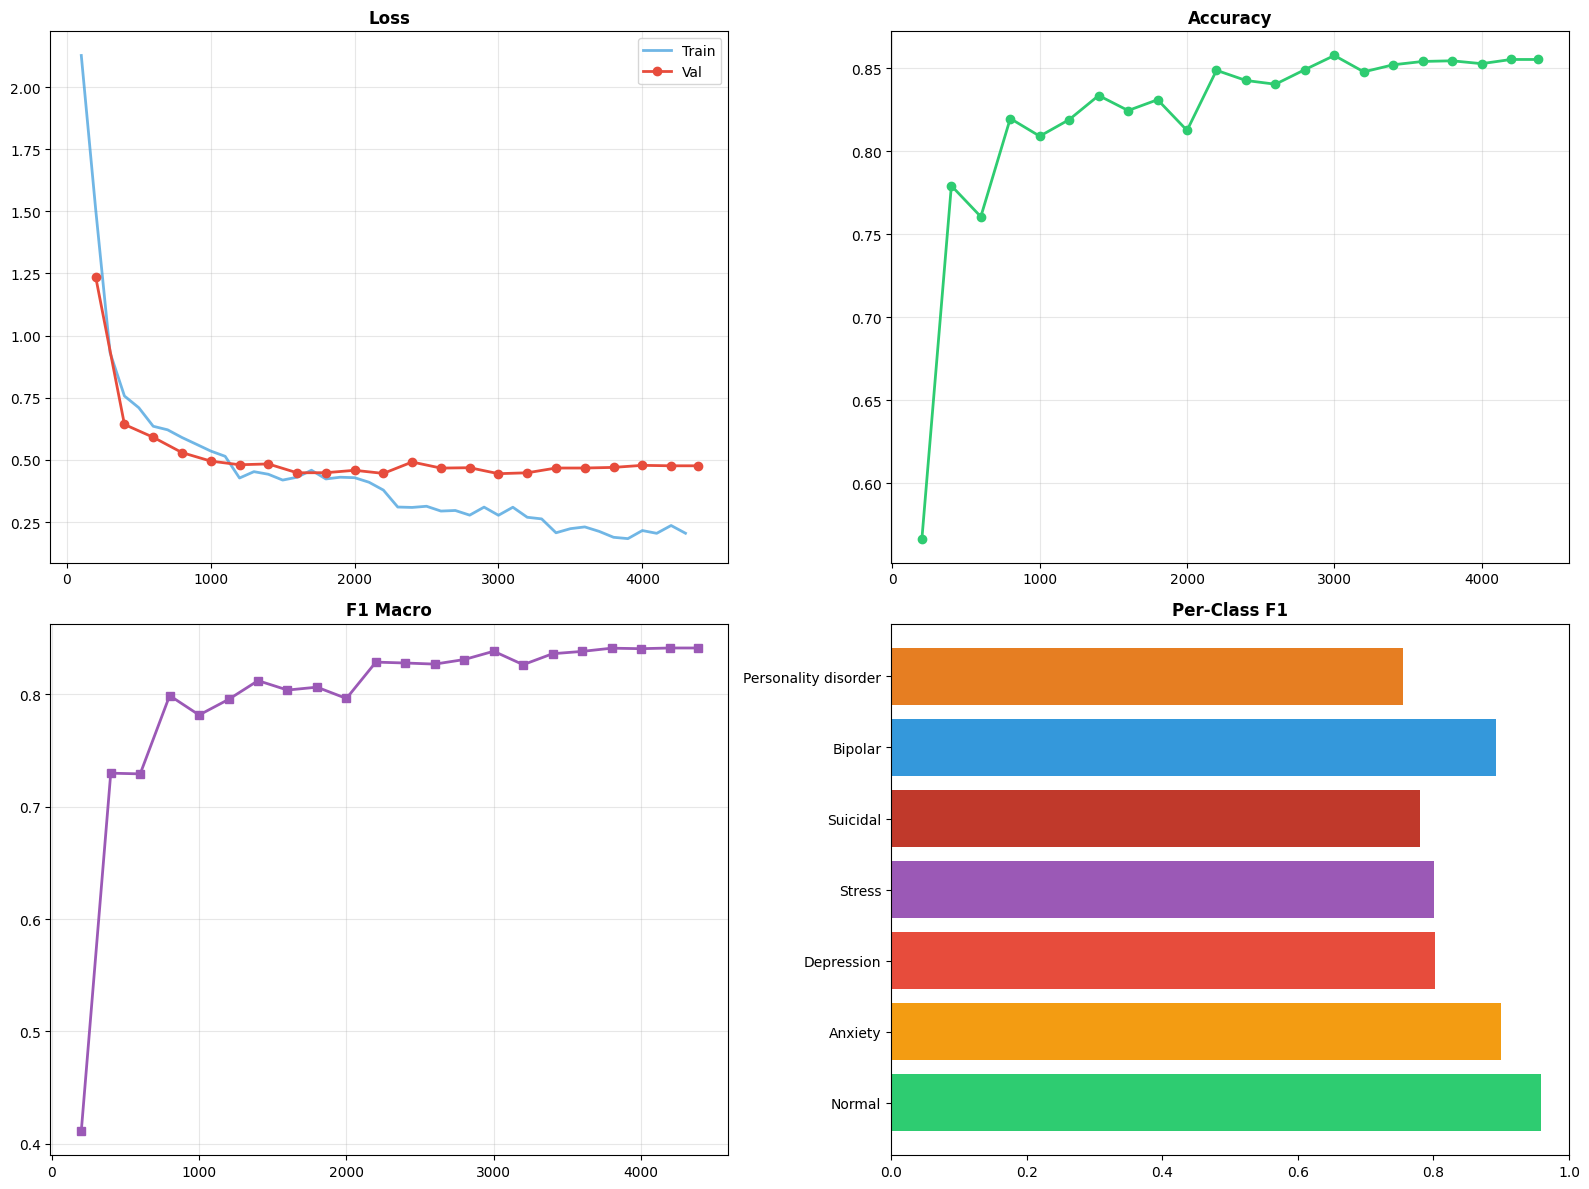

In [12]:

# ============= TRAINING CURVES =============
log_history = trainer.state.log_history

train_loss = [x['loss'] for x in log_history if 'loss' in x]
train_steps = [x['step'] for x in log_history if 'loss' in x]
eval_loss = [x['eval_loss'] for x in log_history if 'eval_loss' in x]
eval_acc = [x['eval_accuracy'] for x in log_history if 'eval_accuracy' in x]
eval_f1_macro = [x['eval_f1_macro'] for x in log_history if 'eval_f1_macro' in x]
eval_steps = [x['step'] for x in log_history if 'eval_loss' in x]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].plot(train_steps, train_loss, label='Train', linewidth=2, color='#3498db', alpha=0.7)
axes[0, 0].plot(eval_steps, eval_loss, label='Val', linewidth=2, color='#e74c3c', marker='o')
axes[0, 0].set_title('Loss', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(eval_steps, eval_acc, linewidth=2, color='#2ecc71', marker='o')
axes[0, 1].set_title('Accuracy', fontweight='bold')
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(eval_steps, eval_f1_macro, linewidth=2, color='#9b59b6', marker='s')
axes[1, 0].set_title('F1 Macro', fontweight='bold')
axes[1, 0].grid(alpha=0.3)

class_f1 = [val_results.get(f'eval_f1_{c.lower().replace(" ","_").replace("-","_")}', 0) for c in class_names]
axes[1, 1].barh(class_names, class_f1, color=['#2ecc71', '#f39c12', '#e74c3c', '#9b59b6', '#c0392b', '#3498db', '#e67e22'])
axes[1, 1].set_title('Per-Class F1', fontweight='bold')
axes[1, 1].set_xlim([0, 1])

plt.tight_layout()
plt.savefig('results/training_curves.png', dpi=300, bbox_inches='tight')
print("+ Saved: results/training_curves.png")
